In [1]:
# Autoencoders 

# Autoencoders

## Overview
- A **class of unsupervised neural networks**
- Used to learn **efficient representations (encodings)** of data
- **Main goal:** compress input data and then reconstruct it as accurately as possible

---

## How Autoencoders Work
An autoencoder learns a function that maps input data to a compressed representation and back:

\[
x \;(\text{original input}) \;\rightarrow\; \text{Encoder} \;\rightarrow\; z \;(\text{compressed representation}) \;\rightarrow\; \text{Decoder} \;\rightarrow\; \hat{x} \;(\text{reconstructed input})
\]

- The network is trained to **minimize reconstruction error** between \(x\) and \(\hat{x}\)

---

## Architecture of an Autoencoder

### 1. Encoder
- Compresses the input data
- Learns meaningful features
- Reduces dimensionality

\[
z = f(Wx + b)
\]

Where:
- \(W\) = weight matrix  
- \(b\) = bias term  
- \(f(\cdot)\) = activation function  

---

### 2. Latent Space (Bottleneck Layer)
- A smaller hidden layer that **forces the model to learn important features**
- Removes **noise and redundancy**
- Represents the compressed version of the input

---

### 3. Decoder
- Reconstructs the input from the latent features

\[
\hat{x} = g(W'z + b')
\]

Where:
- \(W'\) = decoder weights  
- \(b'\) = decoder bias  
- \(g(\cdot)\) = activation function  

---

## Applications of Autoencoders
- **Dimensionality reduction** - reduce features before ML models
- **Noise reduction (denoising autoencoders)**
- **Feature extraction** - limit features 
- **Anomaly detection**
- **Data compression**


In [2]:
import sys
print(sys.executable)
print(sys.version)


/Users/angelajohnson/miniforge3/envs/tfarm/bin/python
3.10.19 (main, Oct 21 2025, 16:37:10) [Clang 20.1.8 ]


In [3]:
pip install tensorflow


  Using cached tensorflow-2.20.0-cp310-cp310-macosx_12_0_arm64.whl.metadata (4.5 kB)
Using cached tensorflow-2.20.0-cp310-cp310-macosx_12_0_arm64.whl (200.4 MB)
Note: you may need to restart the kernel to use updated packages.


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model

In [5]:
(x_train,_), (x_test,_) = fashion_mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [6]:
latent_dim = 64

class Autoencoder(Model):
    def __init__(self, latent_dim):
        super(Autoencoder, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = tf.keras.Sequential([layers.Flatten(), layers.Dense(latent_dim, activation='relu'),])
        self.decoder = tf.keras.Sequential([layers.Dense(784, activation='sigmoid'), layers.Reshape((28,28))])

    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

autoencoder = Autoencoder(latent_dim)

In [7]:
autoencoder.compile(optimizer='adam', loss=losses.MeanSquaredError())

In [8]:
autoencoder.fit(x_train, x_train,
                epochs=10,
                shuffle=True,
                validation_data = (x_test, x_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 903us/step - loss: 0.0242 - val_loss: 0.0134
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 708us/step - loss: 0.0117 - val_loss: 0.0107
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 693us/step - loss: 0.0101 - val_loss: 0.0098
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 751us/step - loss: 0.0094 - val_loss: 0.0093
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 668us/step - loss: 0.0091 - val_loss: 0.0091
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 667us/step - loss: 0.0090 - val_loss: 0.0090
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 676us/step - loss: 0.0089 - val_loss: 0.0089
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 694us/step - loss: 0.0088 - val_loss: 0.0088
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 706us/step - loss: 0.0087 - val_loss: 0.0088
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 672us/step - loss: 0.0087 - val_loss: 0.0088


In [9]:
encoded_imgs = autoencoder.encoder(x_test).numpy()
decoded_imgs = autoencoder.decoder(encoded_imgs).numpy()

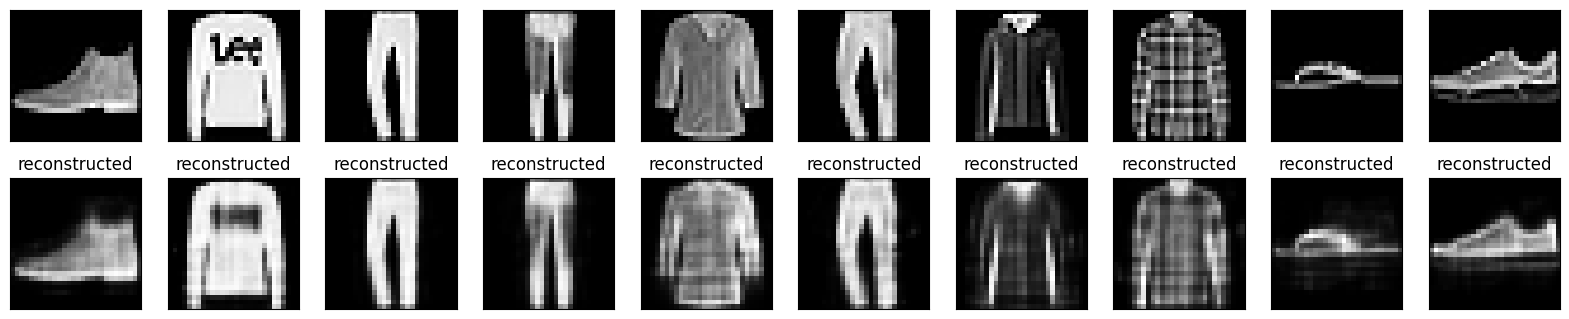

In [10]:
n=10
plt.figure(figsize=(20,4))
for i in range(n):
    ax = plt.subplot(2,n, i+1)
    plt.imshow(x_test[i])
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    ax = plt.subplot(2, n, i+1+n)
    plt.imshow(decoded_imgs[i])
    plt.title("reconstructed")
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()